In [ ]:
# SECTION 0 — IMPORTS
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb        # pip install xgboost
import lightgbm as lgb        # pip install lightgbm


# ── Scikit-learn: evaluation metrics ───
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc,
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings('ignore')   # suppress convergence and deprecation noise

# ── Global plot style ──

sns.set_theme(style='whitegrid', font_scale=1.0)

# Colour palette: 7 distinct colours — one per bean variety
PALETTE = {
    'BARBUNYA': '#E07B54',
    'BOMBAY'  : '#5B8DB8',
    'CALI'    : '#6CB87A',
    'DERMASON': '#B87BB8',
    'HOROZ'   : '#D4A83A',
    'SEKER'   : '#5BA8B8',
    'SIRA'    : '#B85B5B',
}

RANDOM_STATE = 42   # fix all random seeds for reproducibility
FIGSIZE      = (14, 5)


In [ ]:

# SECTION 1 — DATA LOADING & FIRST INSPECTION
# ─────────────────────────────────────────────────────────────────────────────


print("=" * 65)
print("  SECTION 1 — DATA LOADING & INSPECTION")
print("=" * 65)

df = pd.read_excel('Beans_Dataset.xlsx')   # ← adjust path if needed

print(f"\n  Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n  Column names:\n  {df.columns.tolist()}")

# .head() previews the first 5 rows — quick sanity check on column types
print(f"\n  First 5 rows:\n{df.head()}")

# .info() shows dtype and non-null count for every column
print("\n  Column info:")
df.info()

# .describe() gives count, mean, std, min, quartiles, max for numeric columns
print("\n  Descriptive statistics:")
print(df.describe().round(3).T)   # .T transposes for easier reading

  SECTION 1 — DATA LOADING & INSPECTION

  Dataset shape  : 13,611 rows × 17 columns

  Column names:
  ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

  First 5 rows:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134              NaN       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812     28715.0     190.141097  0.763923  0.988856   0.958027   
1      0.411785     29172.0     191.272750  0.783968


  SECTION 2 — DATA QUALITY CHECKS

 Missing values:
                 Missing Count  Missing %
MajorAxisLength              2      0.015
AspectRation                 2      0.015
ConvexArea                   1      0.007
Solidity                     1      0.007
Compactness                  1      0.007

  Duplicate rows: 68

  Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


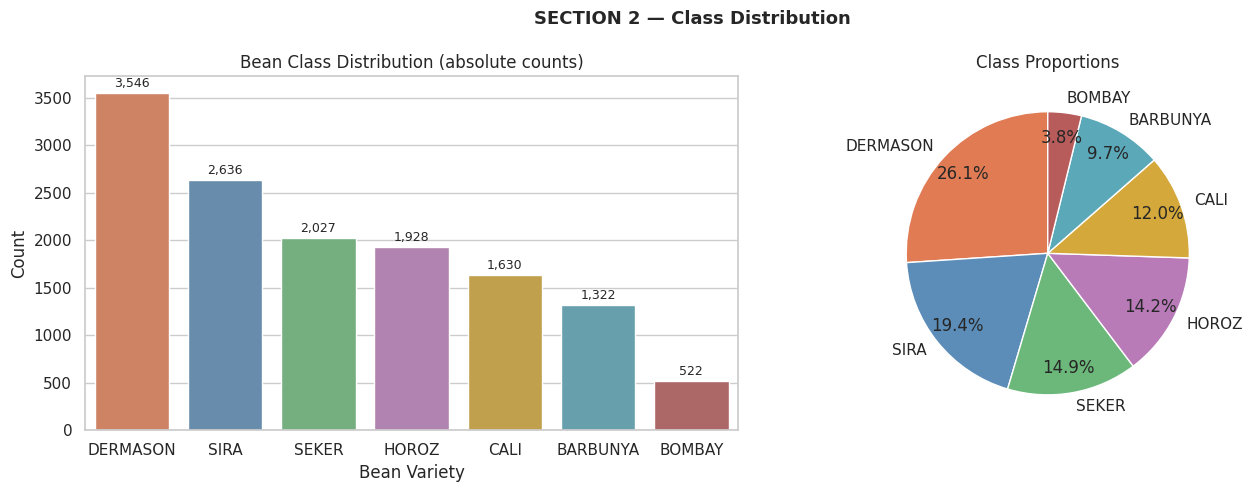

In [ ]:

# SECTION 2 — DATA QUALITY CHECKS
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  SECTION 2 — DATA QUALITY CHECKS")
print("=" * 65)

# (a) Missing values per column
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(3)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print("\n Missing values:")
print(missing_df[missing_df['Missing Count'] > 0])
# Result: 6 NaN cells across MajorAxisLength, AspectRation,
#         ConvexArea, Solidity, Compactness — negligible (< 0.05%)

# (b) Duplicate rows
n_dup = df.duplicated().sum()
print(f"\n  Duplicate rows: {n_dup}")

# (c) Class distribution — visualise
print("\n  Class distribution:")
class_counts = df['Class'].value_counts()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Bar chart of raw counts
sns.barplot(x=class_counts.index, y=class_counts.values,
            palette=list(PALETTE.values()), ax=axes[0])
axes[0].set_title('Bean Class Distribution (absolute counts)')
axes[0].set_xlabel('Bean Variety')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart of proportions
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=list(PALETTE.values()),
            startangle=90, pctdistance=0.82)
axes[1].set_title('Class Proportions')

plt.suptitle('SECTION 2 — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sec2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# Observation: BOMBAY (522) is severely under-represented vs DERMASON (3,546).
# This imbalance means accuracy alone is a misleading metric — we use Macro-F1.

In [ ]:

# SECTION 3 — DATA CLEANING & PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  SECTION 3 — DATA CLEANING & PREPROCESSING")
print("=" * 65)

# 3a. Feature / target separation
FEATURE_COLS = [c for c in df.columns if c != 'Class']
TARGET_COL   = 'Class'

X_raw = df[FEATURE_COLS].copy()
y_raw = df[TARGET_COL].copy()

# 3b. Median imputation
print(f"\n  Missing values before imputation : {X_raw.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)
X_df = pd.DataFrame(X_imputed, columns=FEATURE_COLS)

print(f"  Missing values after imputation : {X_df.isnull().sum().sum()}")
# 3c. Label encoding — BARBUNYA→0, BOMBAY→1, CALI→2, DERMASON→3, HOROZ→4, SEKER→5, SIRA→6
le = LabelEncoder()
y  = le.fit_transform(y_raw)
CLASS_NAMES = le.classes_
print(f"  Encoded classes: {dict(zip(CLASS_NAMES, le.transform(CLASS_NAMES)))}")

# 3d. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y
)
print(f"\n  Train : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows")

# 3e. Feature scaling (StandardScaler)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_sc   = scaler.transform(X_test)        # only transform test (no fitting!)
X_all_sc    = scaler.fit_transform(X_df.values)  # full scaled set for visualisation

print("  Scaling complete — mean ≈ 0, std ≈ 1 for all features.")
print(f"  Feature means after scaling  : {X_train_sc.mean(axis=0).round(3)[:5]} ...")
print(f"  Feature stds after scaling   : {X_train_sc.std(axis=0).round(3)[:5]} ...")


  SECTION 3 — DATA CLEANING & PREPROCESSING
  Missing values after imputation : 0
  Encoded classes: {'BARBUNYA': np.int64(0), 'BOMBAY': np.int64(1), 'CALI': np.int64(2), 'DERMASON': np.int64(3), 'HOROZ': np.int64(4), 'SEKER': np.int64(5), 'SIRA': np.int64(6)}

  Train : 10,888 rows  |  Test : 2,723 rows
  Scaling complete — mean ≈ 0, std ≈ 1 for all features.
  Feature means after scaling  : [ 0. -0. -0.  0. -0.] ...
  Feature stds after scaling   : [1. 1. 1. 1. 1.] ...



  SECTION 4 — UNIVARIATE VISUALISATION


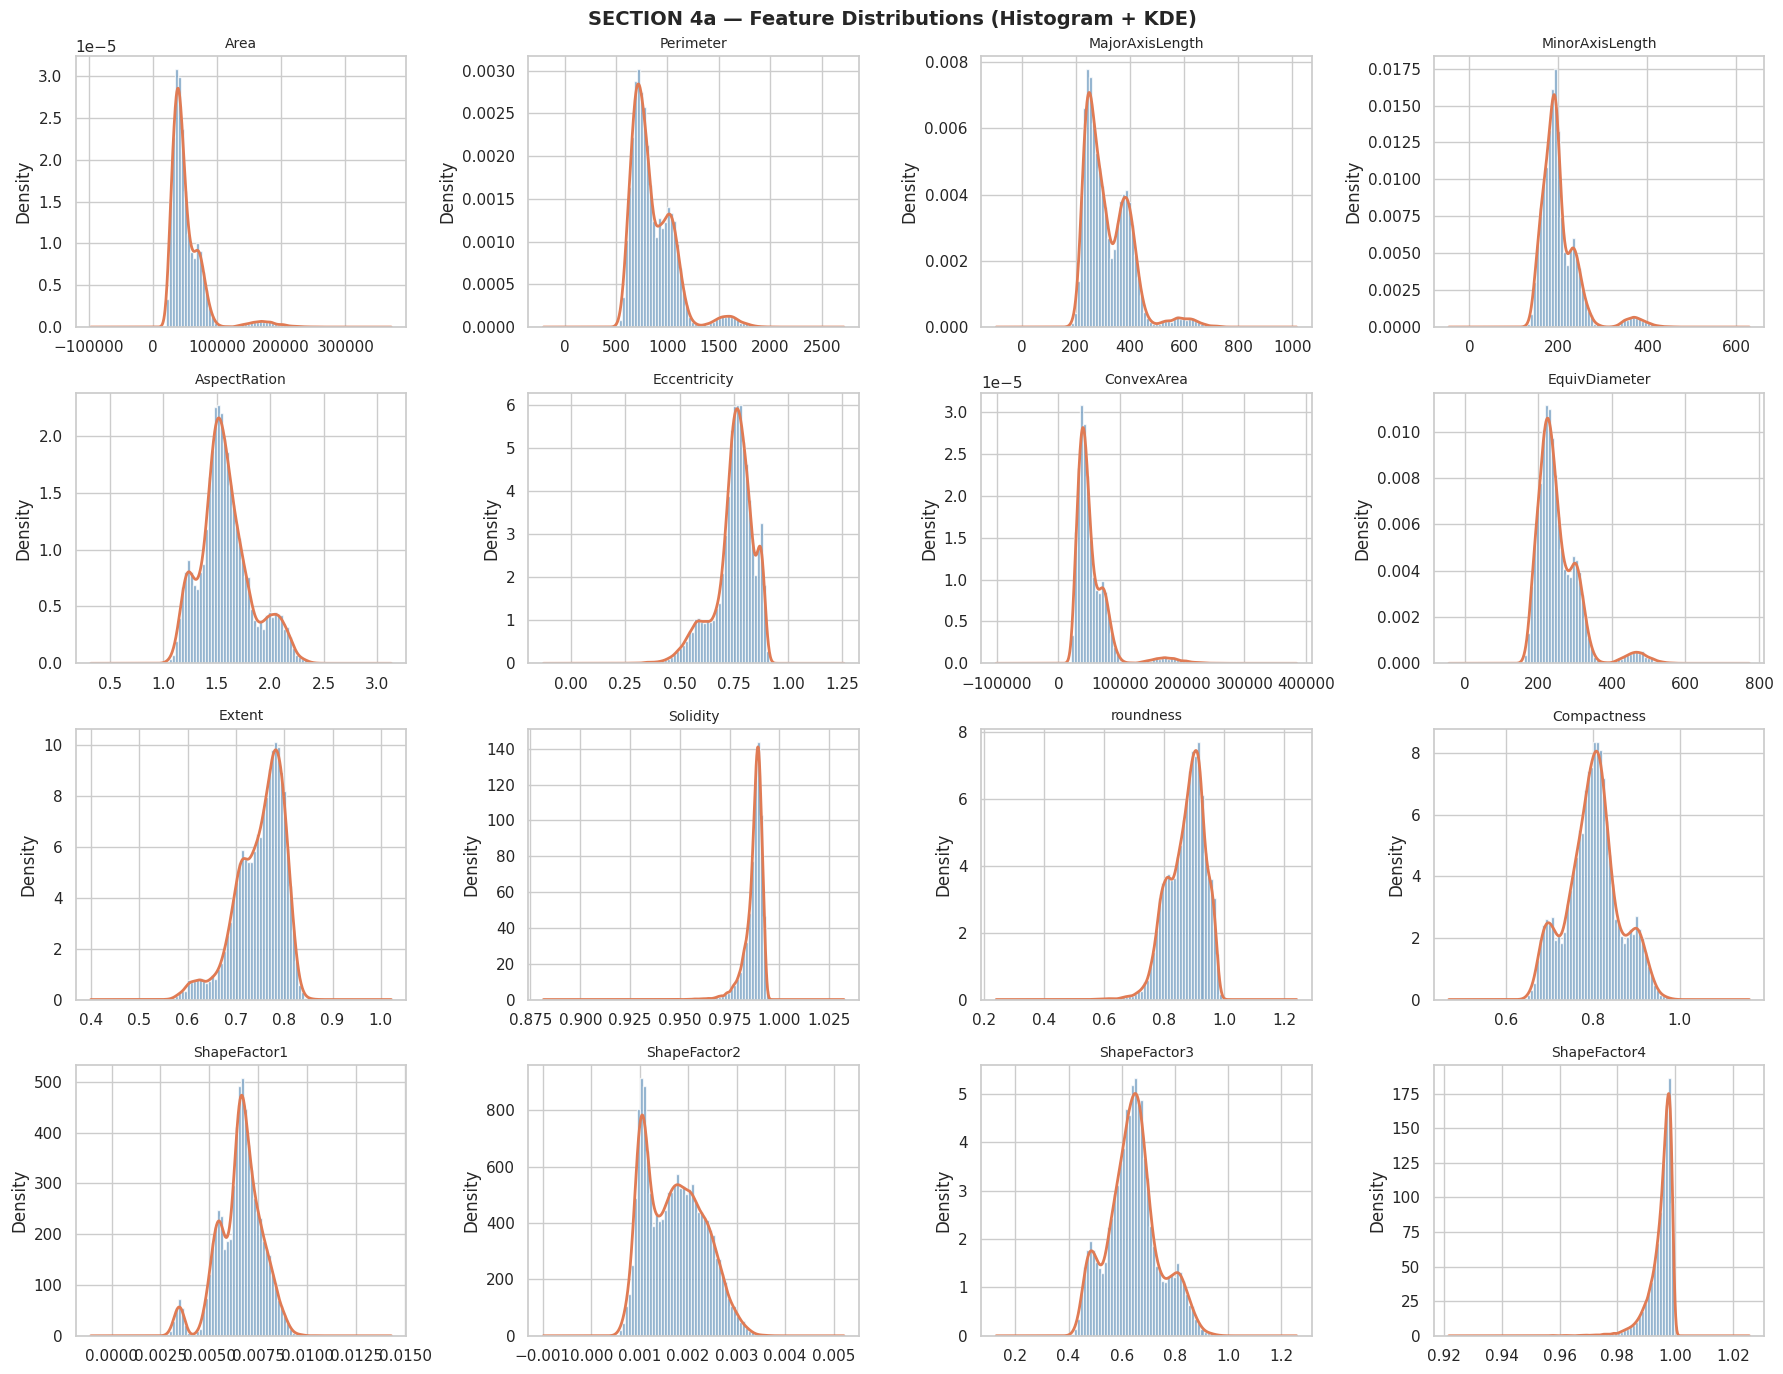

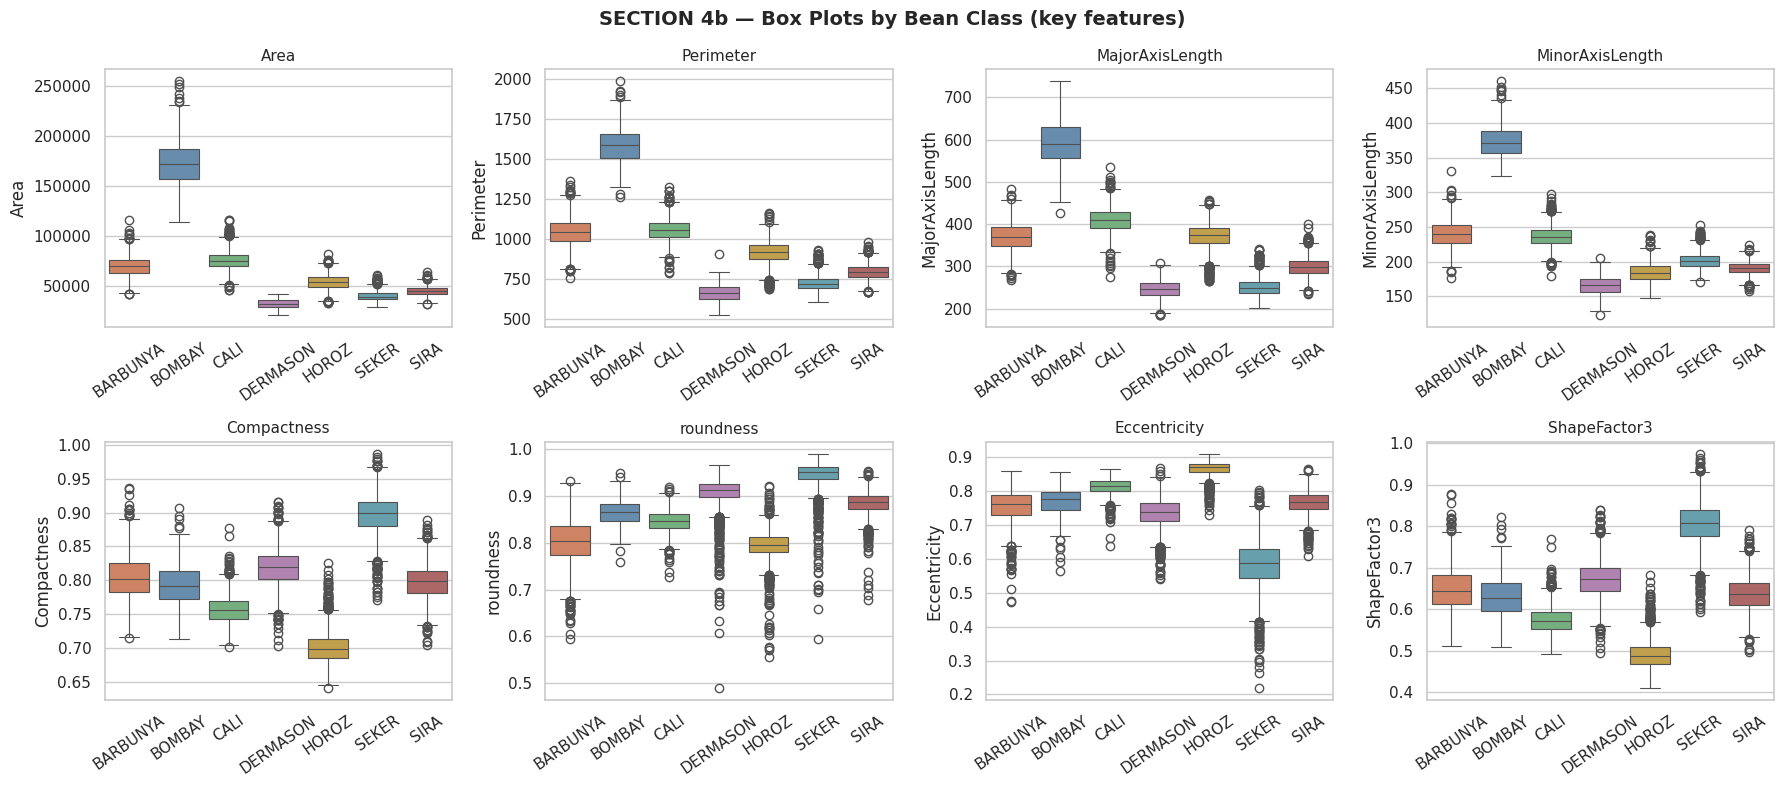


  Outlier counts per feature (IQR method):
Eccentricity       843
Solidity           778
ShapeFactor4       767
MinorAxisLength    569
Area               551
ConvexArea         550
ShapeFactor1       533
EquivDiameter      526
Perimeter          500
AspectRation       473
MajorAxisLength    379
Extent             275
ShapeFactor3       195
Compactness        109
roundness           91
ShapeFactor2         0
dtype: int64


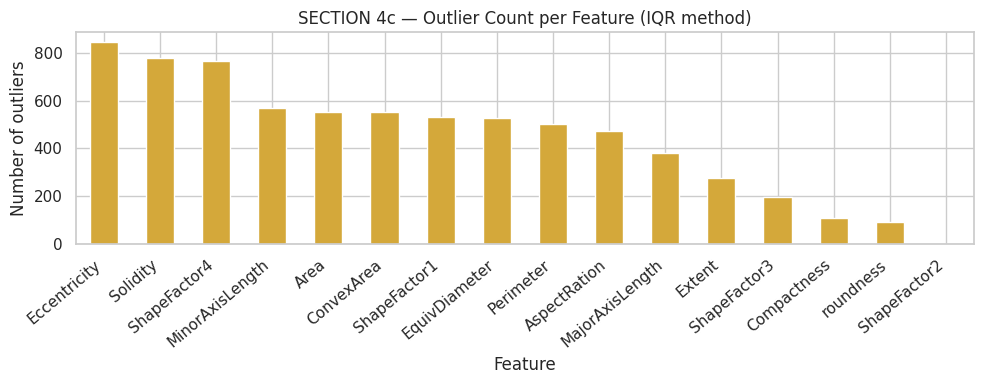

In [ ]:

# SECTION 4 — UNIVARIATE VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  SECTION 4 — UNIVARIATE VISUALISATION")
print("=" * 65)

# ── 4a. Histogram grid — distribution of every feature ───

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(X_df[col], bins=50, color='#5B8DB8', edgecolor='white',
                 alpha=0.75, density=True)
    # KDE overlay using scipy (seaborn calls it internally)
    X_df[col].plot(kind='kde', ax=axes[i], color='#E07B54', lw=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

plt.suptitle('SECTION 4a — Feature Distributions (Histogram + KDE)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sec4a_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4b. Box plots grouped by bean class ───

df_clean = X_df.copy()
df_clean['Class'] = y_raw.values   # re-attach original string labels

KEY_FEATURES = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'Compactness', 'roundness', 'Eccentricity', 'ShapeFactor3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    sns.boxplot(data=df_clean, x='Class', y=col,
                palette=PALETTE, ax=axes[i], linewidth=0.8,
                order=CLASS_NAMES)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)

plt.suptitle('SECTION 4b — Box Plots by Bean Class (key features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sec4b_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4c. Outlier detection — IQR method ───

print("\n  Outlier counts per feature (IQR method):")
outlier_counts = {}
for col in FEATURE_COLS:
    Q1, Q3 = X_df[col].quantile(0.25), X_df[col].quantile(0.75)
    IQR     = Q3 - Q1
    mask    = (X_df[col] < Q1 - 1.5*IQR) | (X_df[col] > Q3 + 1.5*IQR)
    outlier_counts[col] = mask.sum()

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_series)

fig, ax = plt.subplots(figsize=(10, 4))
outlier_series.plot(kind='bar', ax=ax, color='#D4A83A', edgecolor='white')
ax.set_title('SECTION 4c — Outlier Count per Feature (IQR method)')
ax.set_ylabel('Number of outliers')
ax.set_xlabel('Feature')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('sec4c_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


  SECTION 5 — BIVARIATE & MULTIVARIATE VISUALISATION


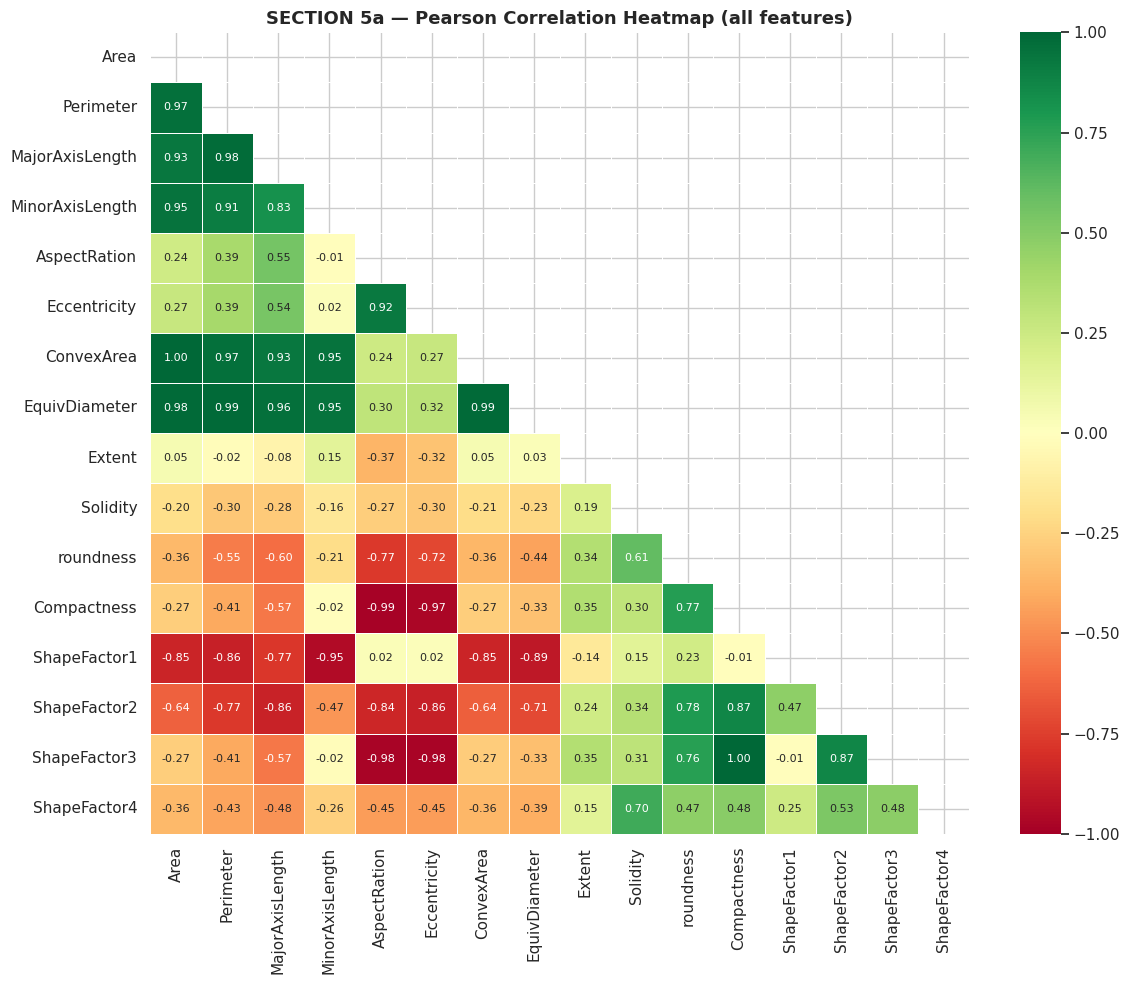


  Highly correlated feature pairs (|r| > 0.90):
    Area                 ↔ ConvexArea            r = 1.0
    Compactness          ↔ ShapeFactor3          r = 0.999
    Perimeter            ↔ EquivDiameter         r = 0.991
    AspectRation         ↔ Compactness           r = -0.987
    Area                 ↔ EquivDiameter         r = 0.985
    ConvexArea           ↔ EquivDiameter         r = 0.985
    Eccentricity         ↔ ShapeFactor3          r = -0.981
    AspectRation         ↔ ShapeFactor3          r = -0.978
    Perimeter            ↔ MajorAxisLength       r = 0.977
    Eccentricity         ↔ Compactness           r = -0.97
    Perimeter            ↔ ConvexArea            r = 0.968
    Area                 ↔ Perimeter             r = 0.967
    MajorAxisLength      ↔ EquivDiameter         r = 0.962
    Area                 ↔ MinorAxisLength       r = 0.952
    MinorAxisLength      ↔ ConvexArea            r = 0.951
    MinorAxisLength      ↔ EquivDiameter         r = 0.949
    Mi

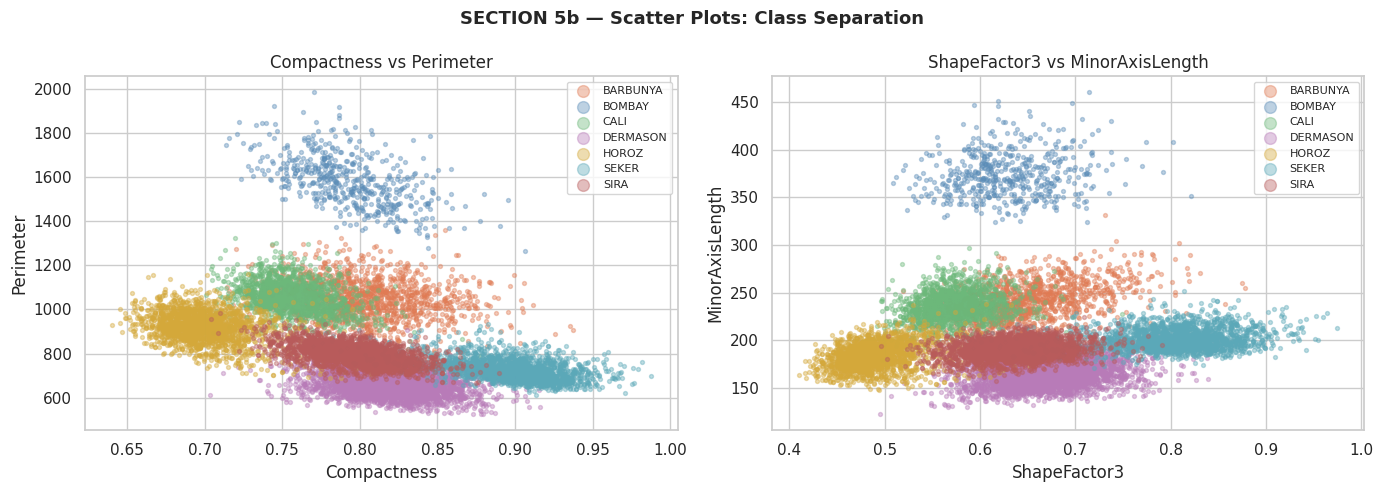

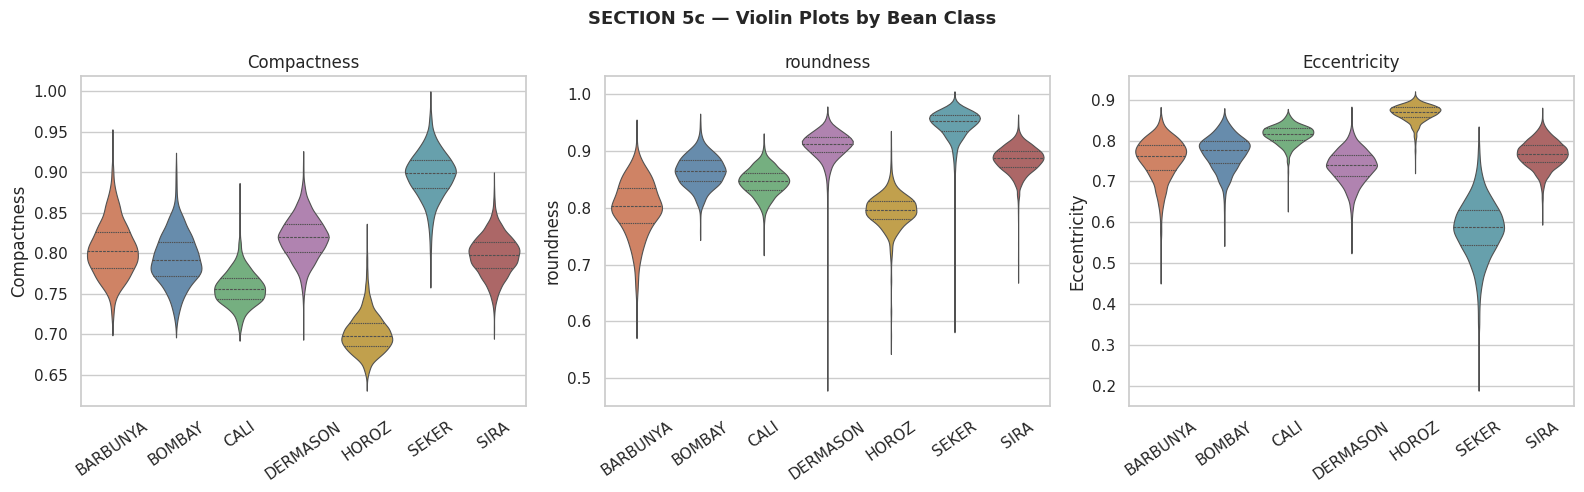

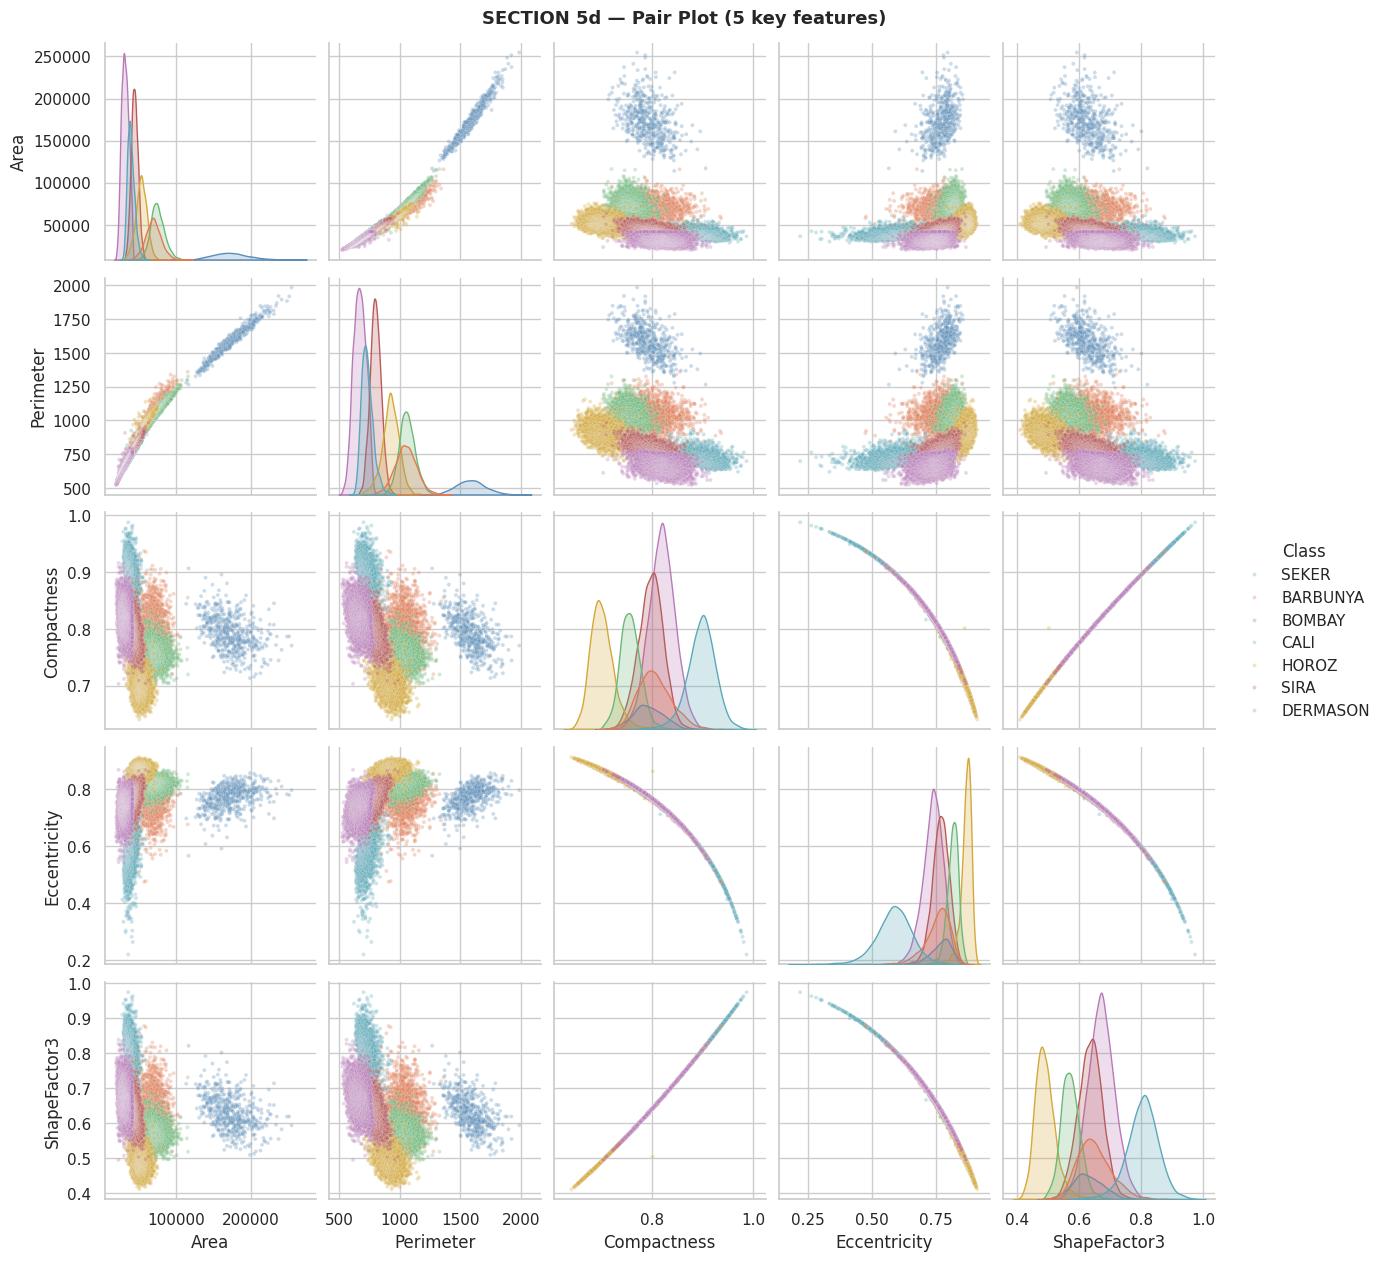

In [ ]:

# SECTION 5 — BIVARIATE & MULTIVARIATE VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
# Examine relationships between pairs and groups of features.

print("\n" + "=" * 65)
print("  SECTION 5 — BIVARIATE & MULTIVARIATE VISUALISATION")
print("=" * 65)

# ── 5a. Correlation heatmap ──
# Pearson correlation r ∈ [−1, 1]:
#   r ≈ +1 → features increase together (high collinearity)
#   r ≈  0 → no linear relationship
#   r ≈ −1 → one increases as the other decreases
# High collinearity (|r| > 0.9) means redundant features — candidates for removal.
corr_matrix = X_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('SECTION 5a — Pearson Correlation Heatmap (all features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sec5a_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print highly correlated pairs (|r| > 0.90)
print("\n  Highly correlated feature pairs (|r| > 0.90):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.90:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

for pair in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"    {pair[0]:20s} ↔ {pair[1]:20s}  r = {pair[2]}")

# ── 5b. Scatter plot — top two separating features ───

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

scatter_pairs = [('Compactness', 'Perimeter'), ('ShapeFactor3', 'MinorAxisLength')]
for ax, (xfeat, yfeat) in zip(axes, scatter_pairs):
    for cls in CLASS_NAMES:
        mask = df_clean['Class'] == cls
        ax.scatter(df_clean.loc[mask, xfeat], df_clean.loc[mask, yfeat],
                   label=cls, color=PALETTE[cls], alpha=0.4, s=8)
    ax.set_xlabel(xfeat)
    ax.set_ylabel(yfeat)
    ax.set_title(f'{xfeat} vs {yfeat}')
    ax.legend(markerscale=3, fontsize=8)

plt.suptitle('SECTION 5b — Scatter Plots: Class Separation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sec5b_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5c. Violin plots — distribution shape per class ───

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Compactness', 'roundness', 'Eccentricity']):
    sns.violinplot(data=df_clean, x='Class', y=col,
                   palette=PALETTE, ax=ax, order=CLASS_NAMES,
                   inner='quartile', linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)

plt.suptitle('SECTION 5c — Violin Plots by Bean Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sec5c_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5d. Pair plot — selected features ────────────────────────────────────────

pair_feats  = ['Area', 'Perimeter', 'Compactness', 'Eccentricity', 'ShapeFactor3']
df_pair     = df_clean[pair_feats + ['Class']].copy()

pair_grid = sns.pairplot(df_pair, hue='Class', palette=PALETTE,
                         plot_kws={'alpha': 0.3, 's': 8},
                         diag_kind='kde', corner=False)
pair_grid.fig.suptitle('SECTION 5d — Pair Plot (5 key features)',
                        y=1.01, fontsize=13, fontweight='bold')
plt.savefig('sec5d_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


  SECTION 6 — FEATURE ENGINEERING
  New features created: ['CompactnessRatio', 'Elongation', 'AreaPerPerimeter', 'ConvexDefect']
       CompactnessRatio  Elongation  AreaPerPerimeter  ConvexDefect
count        13611.0000  13611.0000        13611.0000    13611.0000
mean             0.8733      1.5833           58.8809        0.0128
std              0.0595      0.2466           13.0351        0.0085
min              0.4896      1.0249           34.3476       -0.7432
25%              0.8321      1.4324           51.4395        0.0100
50%              0.8832      1.5513           56.0086        0.0117
75%              0.9169      1.7071           62.6978        0.0143
max              0.9907      2.4303          131.8209        0.3103


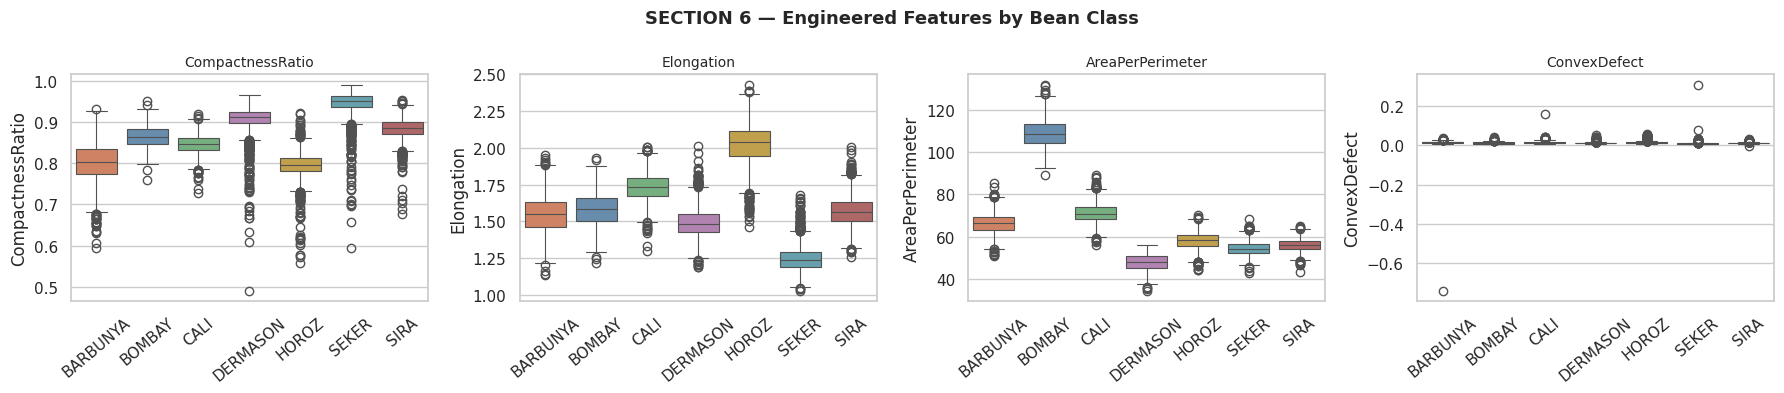

In [ ]:

# SECTION 6 — FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  SECTION 6 — FEATURE ENGINEERING")
print("=" * 65)

# 6a. Compactness ratio: how close the shape is to a circle

df_clean['CompactnessRatio']  = (4 * np.pi * df_clean['Area']) / (df_clean['Perimeter'] ** 2)

# 6b. Elongation: ratio of major to minor axis length

df_clean['Elongation']        = df_clean['MajorAxisLength'] / df_clean['MinorAxisLength']

# 6c. Area per unit perimeter: normalised size feature

df_clean['AreaPerPerimeter']  = df_clean['Area'] / df_clean['Perimeter']

# 6d. Convex hull defect: fraction of area inside convex hull that is "missing"

df_clean['ConvexDefect']      = (df_clean['ConvexArea'] - df_clean['Area']) / df_clean['ConvexArea']

NEW_FEATURES = ['CompactnessRatio', 'Elongation', 'AreaPerPerimeter', 'ConvexDefect']
print(f"  New features created: {NEW_FEATURES}")
print(df_clean[NEW_FEATURES].describe().round(4))

# Visualise new features by class
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, feat in zip(axes, NEW_FEATURES):
    sns.boxplot(data=df_clean, x='Class', y=feat, palette=PALETTE,
                order=CLASS_NAMES, ax=ax, linewidth=0.8)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=40)

plt.suptitle('SECTION 6 — Engineered Features by Bean Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sec6_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Rebuild X with engineered features for modelling
ALL_FEATURES = FEATURE_COLS + NEW_FEATURES
X_eng        = df_clean[FEATURE_COLS + NEW_FEATURES].values
X_eng_train, X_eng_test, _, _ = train_test_split(
    X_eng, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler_eng   = StandardScaler()
X_eng_train_sc = scaler_eng.fit_transform(X_eng_train)
X_eng_test_sc  = scaler_eng.transform(X_eng_test)

In [ ]:

# SECTION 7 — HELPER FUNCTION
# ─────────────────────────────────────────────────────────────────────────────


# Centralised evaluation so every model gets the same report format.
# Prints accuracy, macro-F1, per-class report, and optionally plots
# the confusion matrix.

def evaluate_model(model_name, y_true, y_pred, class_names, plot_cm=True):
    """
    Print a full evaluation report and optionally show the confusion matrix.

    Parameters
    ----------
    model_name  : str   — label for the printed header
    y_true      : array — true integer labels
    y_pred      : array — predicted integer labels
    class_names : list  — original string class names from LabelEncoder
    plot_cm     : bool  — whether to render the confusion matrix heatmap
    """
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    wf1  = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{'─'*60}")
    print(f"  {model_name}")
    print(f"{'─'*60}")
    print(f"  Accuracy         : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Macro-F1         : {mf1:.4f}   ← primary metric (penalises minority class errors)")
    print(f"  Weighted-F1      : {wf1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))

    if plot_cm:
        fig, ax = plt.subplots(figsize=(8, 8))
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'{model_name} — Confusion Matrix', fontsize=12)
        plt.tight_layout()
        plt.savefig(f"{model_name.replace(' ','_').lower()}_confusion_matrix.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

    return {'model': model_name, 'accuracy': acc, 'macro_f1': mf1}


STEP 8 — MODEL 1: LOGISTIC REGRESSION
Training Logistic Regression...

────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────
  Accuracy         : 0.9177  (91.77%)
  Macro-F1         : 0.9314   ← primary metric (penalises minority class errors)
  Weighted-F1      : 0.9180

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.94      0.88      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.92      0.95      0.94       406
        SIRA       0.83      0.89      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



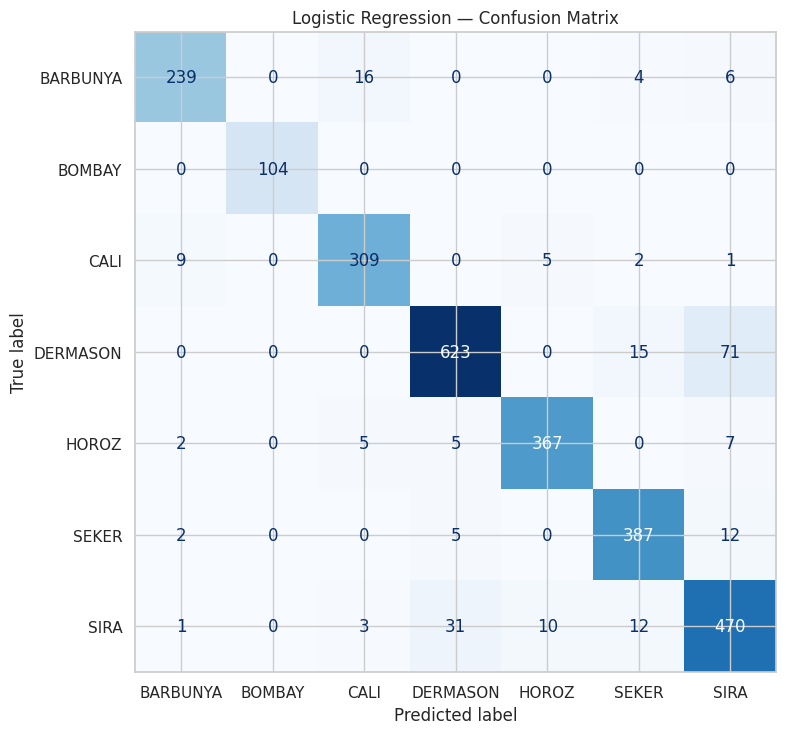


Logistic Regression — coefficient magnitudes (top 5 per class shown):
  BARBUNYA  : most influential features → ['ShapeFactor2', 'ShapeFactor4', 'MinorAxisLength']
  BOMBAY    : most influential features → ['ConvexArea', 'Area', 'MinorAxisLength']
  CALI      : most influential features → ['ShapeFactor1', 'roundness', 'ShapeFactor2']
  DERMASON  : most influential features → ['ShapeFactor1', 'EquivDiameter', 'MajorAxisLength']
  HOROZ     : most influential features → ['ShapeFactor1', 'AspectRation', 'ShapeFactor4']
  SEKER     : most influential features → ['ShapeFactor2', 'ShapeFactor4', 'Eccentricity']
  SIRA      : most influential features → ['Perimeter', 'ConvexArea', 'Area']

Cross-Validation (5-fold Macro-F1): 0.9327 ± 0.0051


In [ ]:

# SECTION 8 — MODEL 1: LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────────────────────


print("\n" + "=" * 60)
print("STEP 8 — MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

lr_pipeline = Pipeline([
    # StandardScaler subtracts the mean and divides by std for every feature.
    # This ensures all 16 features contribute equally to the model.
    ('scaler', StandardScaler()),

    # LogisticRegression with softmax for 7-class output
    ('model', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=42,
    ))
])

# Training: fit() on the training set only (data leakage rule — scaler learns
# the mean/std from training data, never from test data)

print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)

# Prediction on held-out test set

lr_pred = lr_pipeline.predict(X_test)

# Evaluate

lr_results = evaluate_model('Logistic Regression', y_test, lr_pred, le.classes_)


# Coefficients: how each feature shifts the log-odds for each class
#   shape = (n_classes, n_features) → one row per class, one column per feature

lr_coef = pd.DataFrame(
    lr_pipeline.named_steps['model'].coef_,
    index=le.classes_,
    columns=FEATURE_COLS
)
print("\nLogistic Regression — coefficient magnitudes (top 5 per class shown):")
for cls in le.classes_:
    top = lr_coef.loc[cls].abs().nlargest(3).index.tolist()
    print(f"  {cls:10s}: most influential features → {top}")

# 5-Fold Stratified Cross-Validation
#   We use stratified CV so each fold preserves the 7-class imbalance ratio.
#   cross_val_score refits the full pipeline on each fold — scaler is never fitted on the validation fold.

lr_cv = cross_val_score(lr_pipeline, X_df.values, y,
                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                        scoring='f1_macro', n_jobs=-1)
print(f"\nCross-Validation (5-fold Macro-F1): {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")


STEP 9 — MODEL 2: RANDOM FOREST
Training Random Forest (300 trees)...

────────────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────────────
  Accuracy         : 0.9210  (92.10%)
  Macro-F1         : 0.9328   ← primary metric (penalises minority class errors)
  Weighted-F1      : 0.9210

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.91      0.93      0.92       709
       HOROZ       0.97      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.85      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



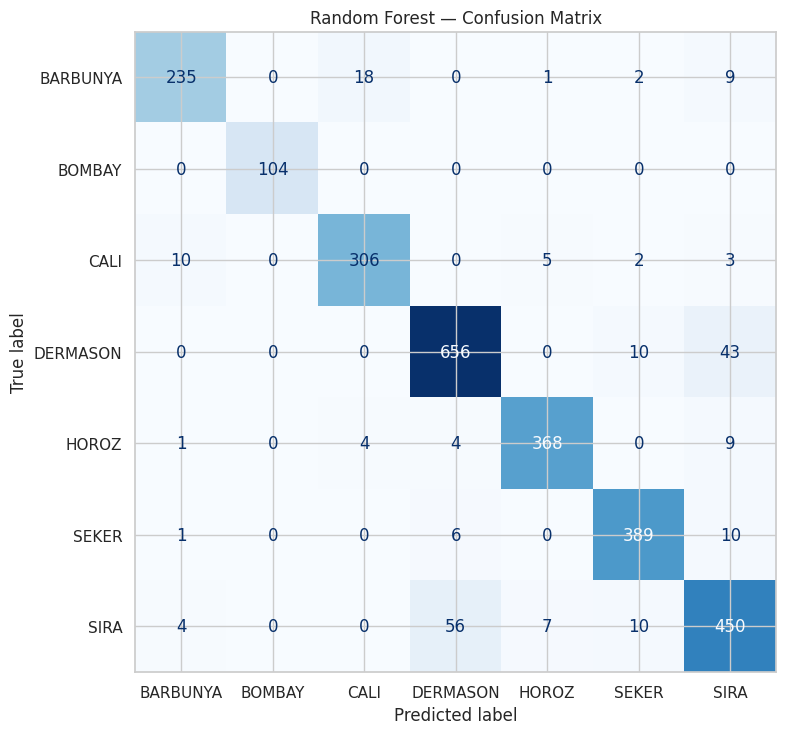


Feature Importances (all 16):
  Compactness          0.1076  
  Perimeter            0.0979  
  MinorAxisLength      0.0923  
  ShapeFactor3         0.0902  
  ShapeFactor1         0.0850  
  ConvexArea           0.0680  
  Area                 0.0667  
  MajorAxisLength      0.0649  
  Eccentricity         0.0619  
  EquivDiameter        0.0614  
  roundness            0.0590  
  AspectRation         0.0573  
  ShapeFactor4         0.0331  
  ShapeFactor2         0.0268  
  Solidity             0.0183  
  Extent               0.0093  


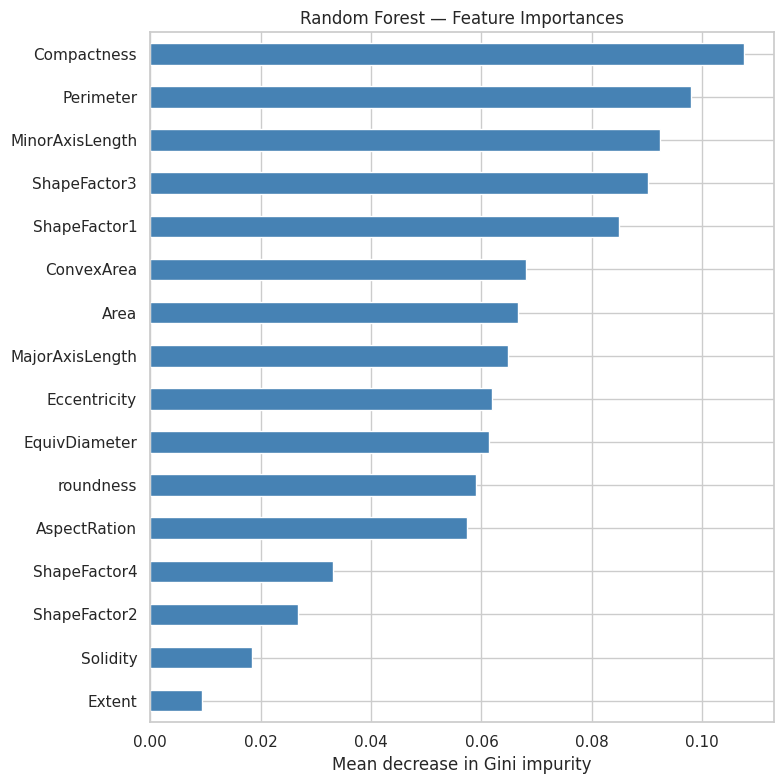


Cross-Validation (5-fold Macro-F1): 0.9356 ± 0.0021


In [ ]:

# SECTION 9 — MODEL 2: RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────


print("\n" + "=" * 60)
print("STEP 9 — MODEL 2: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

print("Training Random Forest (300 trees)...")
rf_model.fit(X_train, y_train)     # no scaling needed — trees are scale-invariant

rf_pred = rf_model.predict(X_test)
rf_results = evaluate_model('Random Forest', y_test, rf_pred, le.classes_)

# Feature importance
#   Random Forest measures importance as the average decrease in Gini impurity across all trees when a feature is used for splitting.
#   Higher = more important.

feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nFeature Importances (all 16):")
for feat, imp in feat_importance.items():

    bar = '' * int(imp * 200)
    print(f"  {feat:20s} {imp:.4f}  {bar}")

# Plot feature importances

fig, ax = plt.subplots(figsize=(8, 8))
feat_importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Mean decrease in Gini impurity')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 5-Fold CV

rf_cv = cross_val_score(rf_model, X_eng, y,
                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                        scoring='f1_macro', n_jobs=-1)
print(f"\nCross-Validation (5-fold Macro-F1): {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")


STEP 10 — MODEL 3: XGBoost
Training XGBoost with early stopping...
[0]	validation_0-mlogloss:1.80215
[50]	validation_0-mlogloss:0.31466
[100]	validation_0-mlogloss:0.21006
[150]	validation_0-mlogloss:0.19712
[200]	validation_0-mlogloss:0.19825
[250]	validation_0-mlogloss:0.20065
[300]	validation_0-mlogloss:0.20470
[350]	validation_0-mlogloss:0.20965
[400]	validation_0-mlogloss:0.21447
[450]	validation_0-mlogloss:0.21857
[499]	validation_0-mlogloss:0.22305

────────────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────────────
  Accuracy         : 0.9232  (92.32%)
  Macro-F1         : 0.9355   ← primary metric (penalises minority class errors)
  Weighted-F1      : 0.9233

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.91      0.

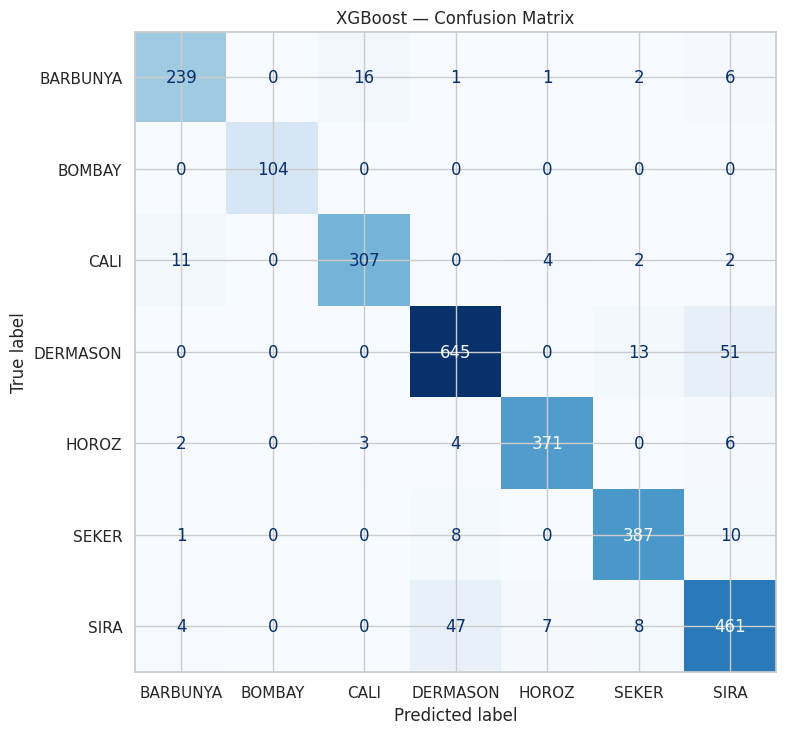


XGBoost — Feature Importances (top 10):
ShapeFactor3       0.167710
Compactness        0.150232
EquivDiameter      0.110587
ConvexArea         0.096007
Area               0.085658
MinorAxisLength    0.075807
ShapeFactor1       0.074678
Eccentricity       0.055518
Perimeter          0.047831
MajorAxisLength    0.035811

Cross-Validation (5-fold Macro-F1): 0.9413 ± 0.0036


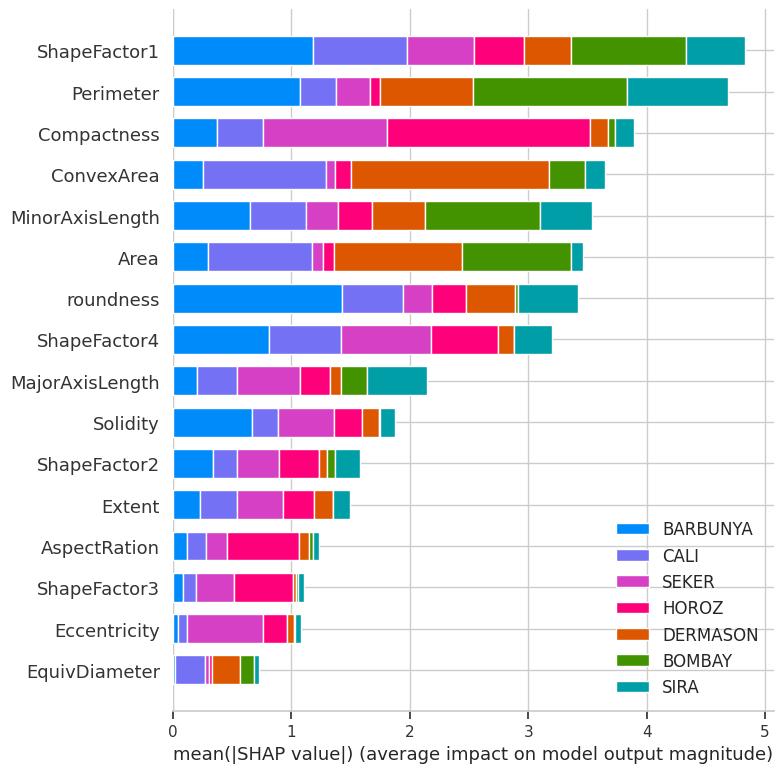

In [ ]:

# SECTION 10 — MODEL 3: XGBoost
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 10 — MODEL 3: XGBoost")
print("=" * 60)

# Compute class weights manually for XGBoost (it uses scale_pos_weight for binary;
# for multi-class we pass sample_weight to fit())

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=7,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

# Early stopping: halt training when validation loss stops improving for 30 rounds
#   eval_set passes a held-out validation set monitored during training

print("Training XGBoost with early stopping...")
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

xgb_pred = xgb_model.predict(X_test)
xgb_results = evaluate_model('XGBoost', y_test, xgb_pred, le.classes_)

# Feature importance from XGBoost (gain-based: total improvement in loss per feature)

xgb_fi = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nXGBoost — Feature Importances (top 10):")
print(xgb_fi.head(10).to_string())

# 5-Fold CV

xgb_cv = cross_val_score(xgb_model, X_eng, y,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         scoring='f1_macro', n_jobs=-1)
print(f"\nCross-Validation (5-fold Macro-F1): {xgb_cv.mean():.4f} \u00b1 {xgb_cv.std():.4f}")

# ── OPTIONAL: SHAP explainability ───

import shap
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:200])  # sample for speed
shap.summary_plot(shap_values, X_test[:200], feature_names=FEATURE_COLS,
                  class_names=le.classes_.tolist(), plot_type='bar')


STEP 11 — MODEL 4: LightGBM
Training LightGBM with early stopping...
[50]	valid_0's multi_logloss: 0.230964
[100]	valid_0's multi_logloss: 0.21708

────────────────────────────────────────────────────────────
  LightGBM
────────────────────────────────────────────────────────────
  Accuracy         : 0.9236  (92.36%)
  Macro-F1         : 0.9361   ← primary metric (penalises minority class errors)
  Weighted-F1      : 0.9237

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92     

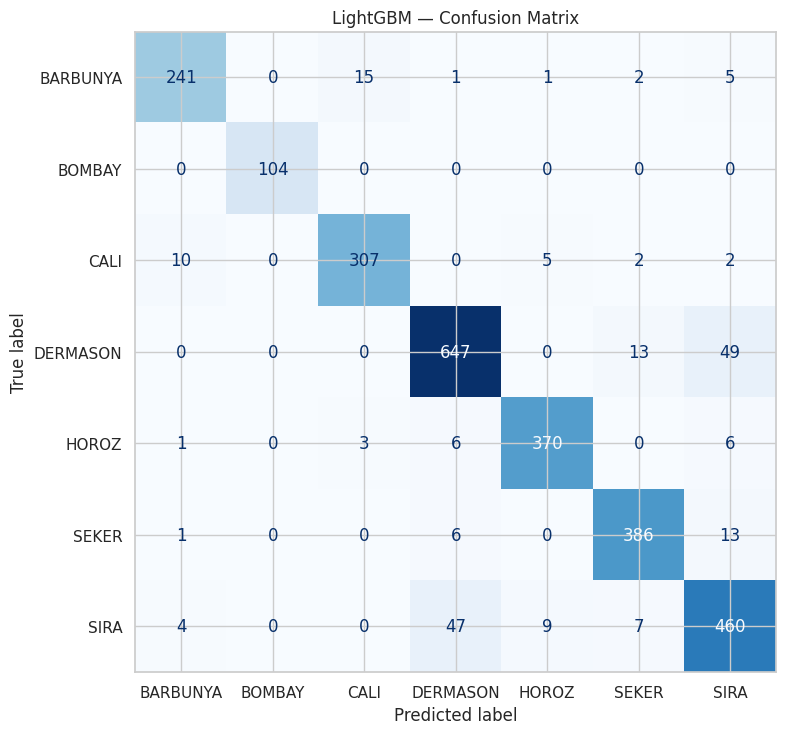


LightGBM — Feature Importances (top 10):
roundness          3338
ShapeFactor4       3325
Solidity           2853
Extent             2766
ShapeFactor1       1700
Compactness        1669
MinorAxisLength    1590
ShapeFactor2       1590
Perimeter          1576
AspectRation       1309

Cross-Validation (5-fold Macro-F1): 0.9402 ± 0.0029


In [ ]:

# SECTION 11 — MODEL 4: LightGBM
# ─────────────────────────────────────────────────────────────────────────────


print("\n" + "=" * 60)
print("STEP 11 — MODEL 4: LightGBM")
print("=" * 60)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# Early stopping via callbacks (LightGBM ≥ 4.0 API)

callbacks = [lgb.early_stopping(stopping_rounds=30, verbose=False),
             lgb.log_evaluation(period=50)]

print("Training LightGBM with early stopping...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],    # validation set for early stopping
    callbacks=callbacks,
)

lgb_pred = lgb_model.predict(X_test)
lgb_results = evaluate_model('LightGBM', y_test, lgb_pred, le.classes_)

# Feature importance (split-based: how many times a feature is used to split)

lgb_fi = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nLightGBM — Feature Importances (top 10):")
print(lgb_fi.head(10).to_string())

# 5-Fold CV

lgb_cv = cross_val_score(lgb_model, X_eng, y,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         scoring='f1_macro', n_jobs=-1)
print(f"\nCross-Validation (5-fold Macro-F1): {lgb_cv.mean():.4f} \u00b1 {lgb_cv.std():.4f}")


STEP 9 — MODEL COMPARISON SUMMARY
              Model  Test Accuracy  Test Macro-F1  CV Macro-F1 Mean  CV Macro-F1 Std
            XGBoost         0.9232         0.9355            0.9413           0.0036
           LightGBM         0.9236         0.9361            0.9402           0.0029
      Random Forest         0.9210         0.9328            0.9356           0.0021
Logistic Regression         0.9177         0.9314            0.9326           0.0124


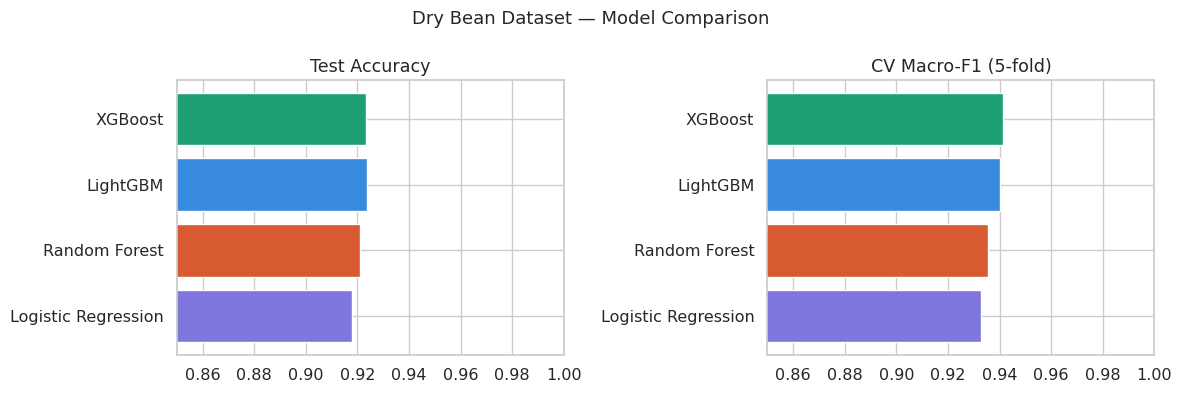


Done. Best model by CV Macro-F1: XGBoost


In [ ]:

# SECTION 9 — MODEL COMPARISON SUMMARY
# ─────────────────────────────────────────────────────────────────────────────


# We collect results and print a ranked leaderboard.
# Macro-F1 is the primary metric because it treats all 7 classes equally

print("\n" + "=" * 60)
print("STEP 9 — MODEL COMPARISON SUMMARY")
print("=" * 60)

results_summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Test Accuracy': lr_results['accuracy'],
     'Test Macro-F1': lr_results['macro_f1'],
     'CV Macro-F1 Mean': lr_cv.mean(), 'CV Macro-F1 Std': lr_cv.std()},
    {'Model': 'Random Forest',       'Test Accuracy': rf_results['accuracy'],
     'Test Macro-F1': rf_results['macro_f1'],
     'CV Macro-F1 Mean': rf_cv.mean(), 'CV Macro-F1 Std': rf_cv.std()},
    {'Model': 'XGBoost',             'Test Accuracy': xgb_results['accuracy'],
     'Test Macro-F1': xgb_results['macro_f1'],
     'CV Macro-F1 Mean': xgb_cv.mean(), 'CV Macro-F1 Std': xgb_cv.std()},
    {'Model': 'LightGBM',            'Test Accuracy': lgb_results['accuracy'],
     'Test Macro-F1': lgb_results['macro_f1'],
     'CV Macro-F1 Mean': lgb_cv.mean(), 'CV Macro-F1 Std': lgb_cv.std()},
]).sort_values('CV Macro-F1 Mean', ascending=False).reset_index(drop=True)

results_summary[['Test Accuracy', 'Test Macro-F1', 'CV Macro-F1 Mean', 'CV Macro-F1 Std']] = \
    results_summary[['Test Accuracy', 'Test Macro-F1', 'CV Macro-F1 Mean', 'CV Macro-F1 Std']].round(4)

print(results_summary.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = results_summary['Model']

axes[0].barh(models, results_summary['Test Accuracy'], color=['#1D9E75','#378ADD','#D85A30','#7F77DD'])
axes[0].set_title('Test Accuracy')
axes[0].set_xlim(0.85, 1.0)
axes[0].invert_yaxis()

axes[1].barh(models, results_summary['CV Macro-F1 Mean'], color=['#1D9E75','#378ADD','#D85A30','#7F77DD'])
axes[1].set_title('CV Macro-F1 (5-fold)')
axes[1].set_xlim(0.85, 1.0)
axes[1].invert_yaxis()

plt.suptitle('Dry Bean Dataset — Model Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDone. Best model by CV Macro-F1:", results_summary.iloc[0]['Model'])

In [ ]:

# SECTION 10 — HYPERPARAMETER TUNING (EXAMPLE FOR BEST MODEL)
# ─────────────────────────────────────────────────────────────────────────────

# For faster search, we use RandomizedSearchCV instead of GridSearchCV.


from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'learning_rate' : [0.01, 0.05, 0.1],
    'max_depth'     : [4, 6, 8],
    'n_estimators'  : [300, 500, 800],
    'subsample'     : [0.7, 0.8, 1.0],
    'num_leaves'    : [31, 63, 127],
}

search = RandomizedSearchCV(
    lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    param_distributions=param_grid,
    n_iter=20,                  # 20 random combinations
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV F1 :", search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05}
Best CV F1 : 0.9422567372834998


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
